### Loan_approval_dataset
- create Df, drop id column
- check null - drop them if present
- check duplicates - drop if present
- drop outliers from income_annum
- create an column from residentail_assets_value, commercial_assets_value luxury_assets_value, bank_assets_value and the name  of the total_assets_value
- drop residential_assets_value,commercial_assets_value luxury_assets_value, bank_assets_value
- target column = loan_status
- features = all other columns left arfter dropping cols(convert it using get_dummies)
- create knn(negibors=10), decissiontree(criterion=entropy,random_state=42),
  randomforest(criterion=entropy,random_state=42), svc(c=20)
- split data for test size (0.1,0.2,0.3,0.4) and keep random_state = 42 and find accuracy for all the models you create for each test size.
-create line plot comparing accuracy of each model for all diffrent test size.

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("loan_approval_dataset.csv")
df

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,NotGraduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,NotGraduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,4266,0,NotGraduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,4267,2,NotGraduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,4268,1,NotGraduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


In [5]:
df.drop("loan_id",inplace=True,axis=1)

In [6]:
df.isna().sum()

no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64

In [7]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
4264    False
4265    False
4266    False
4267    False
4268    False
Length: 4269, dtype: bool

<Axes: ylabel='income_annum'>

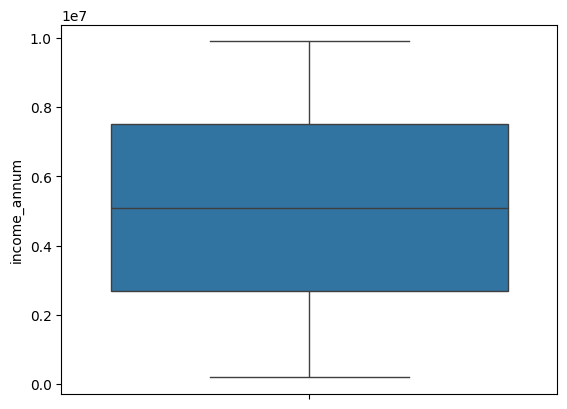

In [9]:
import seaborn as sns
sns.boxplot(df['income_annum'])

In [12]:
df['Total_asset_values'] = df["residential_assets_value"]+df["commercial_assets_value"]+df['luxury_assets_value']+df['bank_asset_value']
df

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,Total_asset_values
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved,50700000
1,0,NotGraduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected,17000000
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected,57700000
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected,52700000
4,5,NotGraduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected,55000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected,7400000
4265,0,NotGraduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved,20000000
4266,2,NotGraduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected,39000000
4267,1,NotGraduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved,28800000


In [17]:
df.drop(["residential_assets_value","commercial_assets_value",'luxury_assets_value','bank_asset_value'],axis=1,inplace=True)

In [18]:
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,loan_status,Total_asset_values
0,2,Graduate,No,9600000,29900000,12,778,Approved,50700000
1,0,NotGraduate,Yes,4100000,12200000,8,417,Rejected,17000000
2,3,Graduate,No,9100000,29700000,20,506,Rejected,57700000
3,3,Graduate,No,8200000,30700000,8,467,Rejected,52700000
4,5,NotGraduate,Yes,9800000,24200000,20,382,Rejected,55000000


In [20]:
x = df.drop(['loan_status'],axis=1)
y=df['loan_status']

In [22]:
x = pd.get_dummies(x,drop_first=True)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score



for i in range(0,4):
    knn = []
    tree = []
    rf = []
    svc = []
    
    count = 0.1
    x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=count,random_state=42)
    count +=0.1
    
    knn = KNeighborsClassifier(n_neighbors=10)
    knn.fit(x_train,y_train)
    y_pred = knn.predict(x_test)
    knn.append[accuracy_score(y_test,y_pred)]
    
    
    dt = DecisionTreeClassifier(criterion="entropy",random_state=42)
    dt.fit(x_train,y_train)
    y_pred = dt.predict(x_test)
    
    rf = RandomForestClassifier(random_state=42,criterion='entropy',n_estimators=100)
    rf.fit(x_train,y_train)
    y_pred = rf.predict(x_test)
    
    s=SVC(kernel='rbf',random_state=42,C=20)
    s.fit(x_train,y_train)
    y_pred=s.predict(x_test)
    

In [39]:
a = int(input())
count=0
ans =[]
for i in range(a):
    b = int(input())
    c = str(input())

    if c[-1] == 'L':
        for j in c:
            if j == 'R':
                count+=1
            else:
                count+=1
                break
        ans.append(count)
        count=0
for k in ans:
    print(k)

2
6


In [26]:
a = int(input())
x = 0
fx = 0
count = 0
for i in range(a):
    b = input()
    c = list(map(int,b))
    x = sum(c)
    x_str = str(x)
    x_arr = list(map(int,x_str))
    fx = sum(x_arr)
    if x == fx:
        print(count)     
    else:
        while(True):
            if sum(c)>9:
                count+=1
                if c.index(max(c)) == 0:
                    c[c.index(max(c))] =1
                    print(c)
                else:
                    c[c.index(max(c))] =0
                    print(c)
            else :
                print(count)
                count = 0
                break

[1, 9]
[1, 0]
2
